In [1]:
import gseapy as gp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test
from lifelines.plotting import add_at_risk_counts

In [2]:
%cd /home/orimosko/projects/phago/downloaded

/home/orimosko/projects/phago/downloaded


In [3]:
PHAGO_COLOR = "#FF97E2"
NONPHAGO_COLOR = "#00A86B"
PBS_COLOR = "#63A7FF"
RODOHIGH_COLOR = "#8A54A5"
GRAY = "#D3D3D3" 

In [4]:
new_up_and_corr_genes_human = [
    "FTH1", "WFDC17", "CCL9", "FABP5", "CSTB", "MARCO", "CTSK", "CD63", "LGALS3",
    "LYZ", "ESD", "FTL", "CD68", "RNH1", "GPNMB", "MT1A", "CAPG", "TUBA1C",
    "CRIP1", "ACP5", "LGALS1", "SOD2", "CALM1", "CALR", "TMSB10", "GAPDH", "NME1",
    "SLC39A2", "MRPL52", "EMP3", "CLEC4D", "ANXA4", "CTSB", "TYMS", "CTSZ", "ANPEP",
    "TCEAL9", "MSR1", "MANF", "CCL17", "CYBA", "ATP5ME", "GLRX", "CD24", "ATP6V1C1",
    "TSPO", "CALM3", "PRDX1", "ATP5MJ", "CTSC", "ANXA5", "MT2A", "BCAP31", "HINT1",
    "VAT1", "ENO1", "PYCARD", "ALDOA", "CAV1", "GLA", "FABP4", "NQO2", "ATP6V0B",
    "MFGE8", "TIMM13"
]

In [5]:
correlated_genes = ['CTSD', 'S100A11', 'PLA2G7', 'LIPA', 'ATP6V1F', 'SAT1', 'CD9', 'ACTB',
       'S100A10', 'SRGN', 'HLA-C', 'LAPTM5', 'SDS', 'HLA-DRB5', 'ANXA2',
       'PSAP', 'B2M', 'GRN', 'DBI', 'FCER1G', 'MMP12', 'FUCA1', 'PFN1',
       'HLA-B', 'PLD3', 'CREG1', 'CCL18', 'PLIN2', 'TXN', 'APOC1', 'CTSS',
       'TYROBP', 'IGSF6', 'GPX1', 'C1QC']

In [6]:
gene_sets = {
    "Effero score": new_up_and_corr_genes_human,
    "Correlated score": correlated_genes
}

## Load Expression DF (RSEM, not z score) and generate gene scores for each patient

In [123]:
df_expr = pd.read_csv("survival_info/uvm_tcga_pan_can_atlas_2018/data_mrna_seq_v2_rsem.txt", sep="\t", index_col=0).drop(columns='Entrez_Gene_Id')

In [124]:
df_expr = df_expr[~df_expr.index.isna()]

In [125]:
df_expr_log = np.log2(df_expr + 1)

In [126]:
res = gp.ssgsea(data=df_expr_log, 
                gene_sets=gene_sets,
                sample_norm_method='rank', 
                weight=0,
                outdir=None)

2026-02-07 15:44:33,559 [WARNING] Found duplicated gene names, values averaged by gene names!


In [127]:
scores = res.res2d.pivot(index='Name', columns='Term', values='ES')
scores.index = scores.index.str[:12]

## Load clinical data

In [128]:
clin = pd.read_csv("survival_info/clinical/clinical.tsv", sep='\t', index_col=0)

In [129]:
clin = clin[['cases.submitter_id', 'demographic.vital_status', 
             'demographic.days_to_death', 'diagnoses.days_to_last_follow_up']].copy()

In [130]:
clin = clin.drop_duplicates(subset='cases.submitter_id')

In [131]:
clin.set_index('cases.submitter_id', inplace=True)

In [132]:
clin['event'] = (clin['demographic.vital_status'] == 'Dead').astype(int)
clin['demographic.days_to_death'] = pd.to_numeric(clin['demographic.days_to_death'], errors='coerce')
clin['time'] = clin['demographic.days_to_death'].fillna(clin['diagnoses.days_to_last_follow_up'])
clin['time'] = pd.to_numeric(clin['time'], errors='coerce')

In [134]:
final_df = clin.join(scores).dropna(subset=['time', 'Effero score', 'Correlated score'])

In [140]:
final_df.shape

(76, 9)

In [146]:
plt.rcParams['pdf.fonttype'] = 42

plt.rcParams.update({
    'font.size': 7,         # Default font size
    'axes.labelsize': 7,    # X and Y axis labels
    'axes.titlesize': 7,    # Title
    'xtick.labelsize': 7,   # X-axis tick labels
    'ytick.labelsize': 7,   # Y-axis tick labels
    'legend.fontsize': 7,   # Legend text
    'figure.titlesize': 7   # Figure title
})


In [192]:
def km_plot(final_df, score_name, split_method='median', save_path=None):
    if split_method == 'median':
        median_score = final_df[score_name].median()
        final_df[f'{score_name}_group'] = (final_df[score_name] >= median_score).astype(int)
    elif split_method == 'quartile':
        low = final_df[score_name].quantile(0.25)
        high = final_df[score_name].quantile(0.75)
        final_df = final_df[(final_df[score_name] <= low) | (final_df[score_name] >= high)].copy()
        final_df[f'{score_name}_group'] = ((final_df[score_name] >= high)).astype(int)
    
    fig, ax = plt.subplots(figsize=(1.77, 1.77))
    kmf = KaplanMeierFitter()

    for name in sorted(final_df[f'{score_name}_group'].unique()):
            grouped_df = final_df[final_df[f'{score_name}_group'] == name]
            
            # Calculate N for this specific group
            n_patients = len(grouped_df)
            group_label = "High" if name == 1 else "Low"
            label_with_n = f"{group_label} (n={n_patients})"
            
            color = PHAGO_COLOR if name == 1 else NONPHAGO_COLOR
            
            kmf.fit(grouped_df['time'], grouped_df['event'], label=label_with_n)
            kmf.plot_survival_function(ci_show=False, color=color, show_censors=True, linewidth=0.75,
                                       censor_styles={'ms': 5, 'linewidth': 0.5,'marker': '|'}, ax=ax)

    # Add stats
    results = logrank_test(final_df[final_df[f'{score_name}_group'] == 1]['time'],
                          final_df[final_df[f'{score_name}_group'] == 0]['time'],
                          final_df[final_df[f'{score_name}_group'] == 1]['event'],
                          final_df[final_df[f'{score_name}_group'] == 0]['event'])

    ax.legend(title=score_name, frameon=False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_xlabel("Days")
    ax.set_ylabel("Survival Probability")
    ax.text(0.2, 0.1, f"Log-Rank P={results.p_value:.4f}", transform=ax.transAxes, ha='center')
    ax.grid(False)
    if save_path:
        plt.savefig(save_path)
    plt.show()


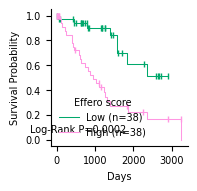

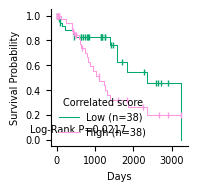

In [193]:
for score in ['Effero score', 'Correlated score']:
    km_plot(final_df, score, 'median', save_path=f"survival_info/uvm_{score.replace(' ', '_').lower()}_km_plot.pdf")